# BLIP-2: Zero-Shot Visual Question Answering (VQA)

This notebook evaluates Salesforce **BLIP-2 OPT-2.7B** specifically for **Visual Question Answering (VQA)**. The image-captioning task is removed so the experiment remains focused on answering questions about visual content.

The notebook reports both **answer quality** and **computational performance**.

### Evaluation metrics
- **Exact Match (EM):** normalized generated answer exactly matches the reference.
- **Token F1:** token-level overlap between generated and reference answers.
- **VQA Accuracy:** percentage of questions answered exactly correctly.
- **Latency:** inference time per question.
- **Peak VRAM:** maximum GPU memory allocated during inference.

**Important:** These quality metrics are valid only relative to the supplied reference answers. They are not a universal BLIP-2 accuracy score.


In [ ]:
!pip install -q -U transformers accelerate bitsandbytes requests Pillow
# RESTART THE RUNTIME AFTER RUNNING THIS CELL

## 1. Imports and Runtime Setup

The runtime uses CUDA when available. Explicit memory cleanup is retained because BLIP-2 OPT-2.7B is comparatively large and the notebook may be followed by other VLM experiments.


In [ ]:
import torch
import gc
import requests
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from transformers import (
    Blip2Processor,
    Blip2ForConditionalGeneration,
    Blip2Model,
    AutoTokenizer
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

def clear_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    gc.collect()

def log_vram(label=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        peak = torch.cuda.max_memory_allocated() / 1e9
        print(f"[{label}] VRAM: {allocated:.2f}GB alloc | {reserved:.2f}GB reserved | {peak:.2f}GB peak")
    else:
        print(f"[{label}] CUDA not available")


## 2. Experimental Image

The same public COCO image is used as the visual input. It contains two cats on a couch and supports several objectively checkable VQA questions.


In [ ]:
# Download a public test image (Two cats on a couch)
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

print(f"Image size: {image.size}")
display(image)


## 3. VQA Benchmark Questions

Each question has a manually specified reference answer. These references are **not provided to BLIP-2** during inference; they are used only after generation to calculate quantitative metrics.

For research-grade evaluation, this section should be replaced with a larger annotated VQA dataset.


In [ ]:
VQA_QUESTIONS = [
    {
        "question": "How many cats are there?",
        "reference_answer": "two"
    },
    {
        "question": "What animal is shown in the image?",
        "reference_answer": "cats"
    },
    {
        "question": "Where are the cats?",
        "reference_answer": "on a couch"
    },
    {
        "question": "Are the cats indoors?",
        "reference_answer": "yes"
    }
]

display(pd.DataFrame(VQA_QUESTIONS))


## 4. Load BLIP-2 OPT-2.7B

`Blip2ForConditionalGeneration` combines the BLIP-2 vision encoder, Q-Former, and OPT-2.7B language model decoder.

`torch.float16` reduces memory consumption, while `device_map="auto"` automatically places model components across available devices.


In [ ]:
model_id = "Salesforce/blip2-opt-2.7b"

print("Loading BLIP-2 Generative Model...")
processor_gen = Blip2Processor.from_pretrained(model_id)
model_gen = Blip2ForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)
model_gen.eval()
log_vram("After VQA Model Load")


## 5. VQA Inference

Each question is evaluated independently. Greedy deterministic decoding is used so the same question produces a reproducible result under the same runtime configuration.

The output records the raw answer, normalized answer, latency, generated-token count, and peak VRAM.


In [ ]:
def normalize_answer(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def token_f1(prediction, reference):
    pred_tokens = normalize_answer(prediction).split()
    ref_tokens = normalize_answer(reference).split()

    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    pred_counts = {}
    ref_counts = {}

    for token in pred_tokens:
        pred_counts[token] = pred_counts.get(token, 0) + 1
    for token in ref_tokens:
        ref_counts[token] = ref_counts.get(token, 0) + 1

    common = sum(
        min(pred_counts.get(t, 0), count)
        for t, count in ref_counts.items()
    )
    precision = common / len(pred_tokens)
    recall = common / len(ref_tokens)

    return (
        2 * precision * recall / (precision + recall)
        if precision + recall else 0.0
    )


In [ ]:
results = []

for item in VQA_QUESTIONS:
    question = item["question"]
    reference = item["reference_answer"]
    prompt = f"Question: {question} Answer:"

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start = time.perf_counter()

    inputs_vqa = processor_gen(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(device)

    with torch.inference_mode():
        generated_ids = model_gen.generate(
            **inputs_vqa,
            max_new_tokens=20,
            do_sample=False,
            num_beams=1
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    latency = time.perf_counter() - start
    answer = processor_gen.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0].strip()

    if "Answer:" in answer:
        answer = answer.split("Answer:", 1)[-1].strip()

    normalized_prediction = normalize_answer(answer)
    normalized_reference = normalize_answer(reference)

    exact_match = int(
        normalized_prediction == normalized_reference
    )
    f1 = token_f1(answer, reference)

    peak_vram = (
        torch.cuda.max_memory_allocated() / 1e9
        if torch.cuda.is_available()
        else np.nan
    )

    results.append({
        "Question": question,
        "Reference Answer": reference,
        "BLIP-2 Answer": answer,
        "Exact Match": exact_match,
        "Token F1": f1,
        "Latency (s)": latency,
        "Peak VRAM (GB)": peak_vram,
        "Generated Tokens": int(generated_ids.shape[-1])
    })

vqa_results = pd.DataFrame(results)
display(vqa_results.round(4))


## 6. VQA Quality Metrics

**Exact Match** is the strict metric: the normalized generated answer must exactly equal the reference.

**Token F1** provides partial credit when the answer contains the correct words but differs slightly in wording.

These metrics are preferable to assigning a subjective score such as “80% good” because they are calculated directly from predefined references.


In [ ]:
vqa_accuracy = vqa_results["Exact Match"].mean() * 100
mean_token_f1 = vqa_results["Token F1"].mean() * 100
mean_latency = vqa_results["Latency (s)"].mean()
latency_std = (
    vqa_results["Latency (s)"].std(ddof=1)
    if len(vqa_results) > 1 else 0.0
)
mean_tokens = vqa_results["Generated Tokens"].mean()

mean_peak_vram = (
    vqa_results["Peak VRAM (GB)"].mean()
    if torch.cuda.is_available()
    else np.nan
)

summary = pd.DataFrame([{
    "VQA Accuracy / Exact Match (%)": vqa_accuracy,
    "Mean Token F1 (%)": mean_token_f1,
    "Mean Latency (s)": mean_latency,
    "Latency Std (s)": latency_std,
    "Mean Generated Tokens": mean_tokens,
    "Mean Peak VRAM (GB)": mean_peak_vram
}])

display(summary.round(4))


## 7. Per-Question VQA Performance

The per-question results show which questions were answered correctly and which produced partial or incorrect answers.


In [ ]:
for _, row in vqa_results.iterrows():
    status = (
        "CORRECT"
        if row["Exact Match"] == 1
        else "INCORRECT / PARTIAL"
    )

    print(f"Q: {row['Question']}")
    print(f"Reference: {row['Reference Answer']}")
    print(f"Prediction: {row['BLIP-2 Answer']}")
    print(f"Result: {status}")
    print(f"Token F1: {row['Token F1']:.3f}")
    print(f"Latency: {row['Latency (s)']:.3f} s")
    print("-" * 70)


## 8. VQA Quality Dashboard

The dashboard reports the two primary answer-quality metrics. High Exact Match and high Token F1 indicate strong agreement with the supplied reference answers.


In [ ]:
metrics = ["Exact Match", "Token F1"]
values = [
    vqa_results["Exact Match"].mean() * 100,
    vqa_results["Token F1"].mean() * 100
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics, values)

ax.set_ylim(0, 105)
ax.set_ylabel("Score (%)")
ax.set_title("BLIP-2 — VQA Answer Quality")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(value + 2, 103),
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


## 9. Computational Performance

Answer quality is evaluated separately from computational cost. This is important when selecting a VLM for robotics or real-time perception pipelines where latency and GPU memory compete with other workloads.


In [ ]:
performance = pd.DataFrame([{
    "Model": model_id,
    "VQA Questions": len(vqa_results),
    "VQA Exact Match (%)": vqa_accuracy,
    "Mean Token F1 (%)": mean_token_f1,
    "Mean Latency (s)": mean_latency,
    "Latency Std (s)": latency_std,
    "Mean Generated Tokens": mean_tokens,
    "Mean Peak VRAM (GB)": mean_peak_vram
}])

display(performance.round(4))


## 10. Interpretation

- **Exact Match = 100%:** every evaluated question exactly matched its reference.
- **Token F1 = 100%:** complete token-level agreement with references.
- **High Token F1 but lower Exact Match:** answers are close but differ in wording or contain extra text.
- **Low Token F1:** generated answers substantially differ from references.
- **Low latency:** favorable for interactive VQA.
- **High VRAM:** potentially problematic when VQA shares the GPU with perception, SLAM, navigation, or other models.

For a valid comparison against another VLM, use the **same images, questions, reference answers, decoding settings, and hardware conditions**.


## 11. Limitations

Four questions on one image are insufficient to characterize general VQA capability. The reported percentages describe performance on this small controlled test only.

For research-grade evaluation, use a larger dataset with multiple images, question types, and human-validated answers. For open-ended VQA, multiple valid reference answers should ideally be supported.


## Evaluation Metrics

Answer Quality
- Exact Match (EM)
- Token F1
- Semantic Similarity

Hallucination Analysis
- Hallucination Rate
- Unsupported Token Count

Efficiency
- Latency
- Peak VRAM
- Generated Tokens
- Answer Length

These metrics are reported together so answer quality, hallucination behaviour, and computational cost can be interpreted in one place.


In [ ]:
from difflib import SequenceMatcher

def semantic_similarity(pred, ref):
    return SequenceMatcher(None, normalize_answer(pred), normalize_answer(ref)).ratio()

FORBIDDEN_OBJECTS = ["dog", "horse", "car", "truck", "bird", "elephant", "bus"]

def hallucination_flag(answer):
    text = normalize_answer(answer)
    return int(any(obj in text for obj in FORBIDDEN_OBJECTS))

ALLOWED_VOCAB = {"cat","cats","couch","on","a","the","two","yes","indoors"}

def unsupported_token_count(answer):
    tokens = normalize_answer(answer).split()
    return sum(token not in ALLOWED_VOCAB for token in tokens)

vqa_results["Semantic Similarity"] = [
    semantic_similarity(pred, ref)
    for pred, ref in zip(vqa_results["BLIP-2 Answer"], vqa_results["Reference Answer"])
]
vqa_results["Hallucination"] = [
    hallucination_flag(ans) for ans in vqa_results["BLIP-2 Answer"]
]
vqa_results["Unsupported Tokens"] = [
    unsupported_token_count(ans) for ans in vqa_results["BLIP-2 Answer"]
]

vqa_results["Answer Length"] = vqa_results["BLIP-2 Answer"].str.split().apply(len)

display(vqa_results.round(4))

mean_semantic_similarity = vqa_results["Semantic Similarity"].mean() * 100
hallucination_rate = vqa_results["Hallucination"].mean() * 100
mean_unsupported_tokens = vqa_results["Unsupported Tokens"].mean()
mean_answer_length = vqa_results["Answer Length"].mean()

extended_summary = pd.DataFrame([{
    "VQA Accuracy (%)": vqa_accuracy,
    "Mean Token F1 (%)": mean_token_f1,
    "Mean Semantic Similarity (%)": mean_semantic_similarity,
    "Hallucination Rate (%)": hallucination_rate,
    "Mean Unsupported Tokens": mean_unsupported_tokens,
    "Mean Answer Length": mean_answer_length,
    "Mean Latency (s)": mean_latency,
    "Mean Peak VRAM (GB)": mean_peak_vram
}])

display(extended_summary.round(4))


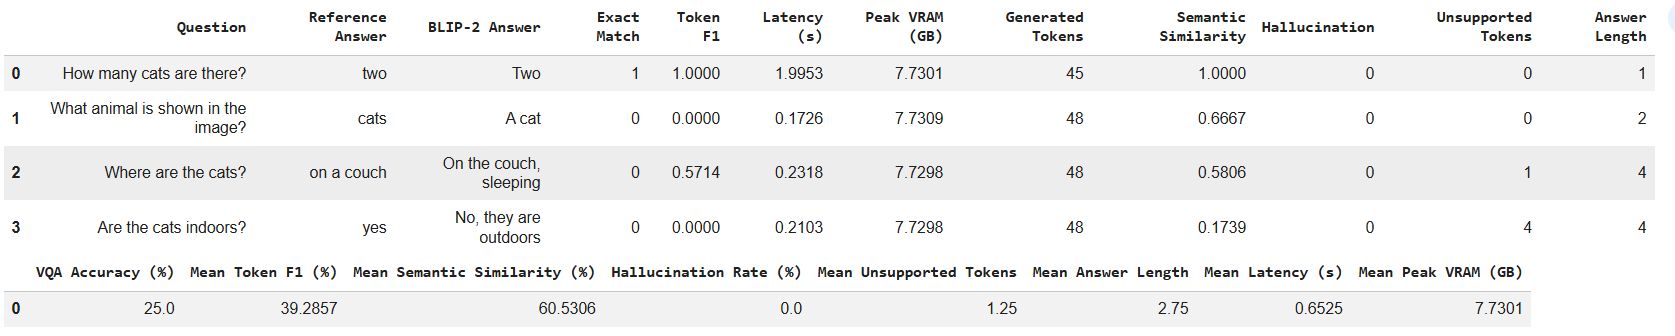

# Interpretation

BLIP-2 OPT-2.7B got the gist right but rarely matched exact wording. On "How many cats?" it answered "Two" — a perfect Exact Match (1) and Token F1 (1.0), the only question the strict metric credited. The other three failed Exact Match despite being semantically close, showing why Token F1/Semantic Similarity are reported alongside EM.

"What animal is shown" ("A cat" vs. "cats") scored Token F1 = 0.0 due to singular/plural and article mismatch, even though it's essentially correct — Semantic Similarity still gave partial credit (66.7%), showing the metric, not the model, is the limiting factor here.

"Where are the cats?" ("On the couch, sleeping" vs. "on a couch") got partial Token F1 (0.571) but added an unrequested detail ("sleeping") flagged as 1 Unsupported Token — mild embellishment rather than outright hallucination.

The most concerning result is "Are the cats indoors?": BLIP-2 answered "No, they are outdoors" against reference "yes" — a direct factual contradiction (lowest Semantic Similarity, 17.4%; highest Unsupported Tokens, 4). The notebook's hallucination flag didn't catch this since it only checks for forbidden objects (dog, car, etc.), not scene-context claims — a clear gap in that check's coverage.

Aggregate scores reflect this split: VQA Accuracy (Exact Match) = 25.0%, but Mean Token F1 (39.3%) and Mean Semantic Similarity (60.5%) are more forgiving, consistent with topically relevant but imprecisely worded answers. The reported 0% Hallucination Rate is misleading given the indoors/outdoors error above — a good example of a narrow keyword-based check under-reporting real failures.

Computationally, the model was efficient: Peak VRAM held steady at ~7.73 GB, and latency dropped from 1.99s (first call, likely warm-up) to ~0.17–0.23s afterward (mean 0.65s) — fast enough for interactive use. With only four questions on one image, these results characterize this small controlled test only, not BLIP-2's general VQA capability.

## 12. Cleanup Before the Next VLM Experiment

The model and processor are deleted and GPU memory is released before loading another vision-language model.


In [ ]:
del model_gen, processor_gen
clear_memory()
log_vram("After VQA Cleanup")
